# TalentCLEF TaskA 2025 Inglés

# Carga de datos

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, classification_report
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
training_data = pd.read_csv("./data/TaskA/training/english/taskA_training_en.tsv", sep='\t', names=['family_id', 'id', 'title1', 'title2'])

validation_data = dict()

validation_data['corpus_elements'] = pd.read_csv("./data/TaskA/validation/english/corpus_elements", sep='\t').set_index('c_id').reset_index(drop=True)

validation_data['queries'] = pd.read_csv("./data/TaskA/validation/english/queries", sep='\t').set_index('q_id').reset_index(drop=True)

validation_data['qrels'] = pd.read_csv("./data/TaskA/validation/english/qrels.tsv", sep='\t', names=['q_id', 'iter', 'c_id', 'relevance'])[['q_id', 'c_id', 'relevance']]
validation_data['qrels']['q_id'] = validation_data['qrels']['q_id'] - 1
validation_data['qrels']['c_id'] = validation_data['qrels']['c_id'] - 1

In [3]:
print("Training data samples:")
print(training_data[['title1', 'title2']].head())
print("\n")

print("Validation data samples:")
print(validation_data['corpus_elements'].head())
print(validation_data['queries'].head())
print(validation_data['qrels'].head())

Training data samples:
                        title1                       title2
0                air commodore            flight lieutenant
1  command and control officer               flight officer
2                air commodore  command and control officer
3                pilot officer              squadron leader
4       royal airforce officer  command and control officer


Validation data samples:
                           jobtitle
0                recording engineer
1              director of taxation
2  technical support representative
3                        hr manager
4           computer graphic artist
              jobtitle
0                nanny
1    food technologist
2   broadcast engineer
3  automation engineer
4         veterinarian
   q_id  c_id  relevance
0     0   142          1
1     0   149          1
2     0   763          1
3     0   869          1
4     0  1463          1


# Aproximación con embedding ya preentrenado

Se establece device='cpu' debido a que mi ordenador no soporta CUDA

## Configuración

In [ ]:
# Version multilingue del modelo
device = 'cpu'
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device=device)

### Ejemplo de uso

In [ ]:
def similarity_between_titles(title1, title2):
    emb1 = model.encode(title1, convert_to_tensor=True, device='cpu')
    emb2 = model.encode(title2, convert_to_tensor=True, device='cpu')

    similarity = util.cos_sim(emb1, emb2)

    return similarity.item()

similarity_between_titles("data scientist", "científico de datos")

0.963962197303772

## Busqueda de threshold mediante datos de entrenamiento

### Grafo de relaciones en entrenamiento

In [ ]:
# se define un grafo con las conexiones entre títulos en los datos de entrenamiento

G = nx.Graph()
for index, row in training_data.iterrows():
    G.add_edge(row['title1'], row['title2'])    

print(f"Número de nodos en el grafo: {G.number_of_nodes()}")

connected_components = list(nx.connected_components(G))
print(f"Número de componentes conexas: {len(connected_components)}")

nodes_list = list(G.nodes)

Número de nodos en el grafo: 26190
Número de componentes conexas: 4270


In [ ]:
# para minimizar tiempo de respuesta, seleccionar aleatoriamente 1000 componentes conexas del total (4270)
np.random.seed(0)
selected_components = np.random.choice(len(connected_components), size=1000, replace=False)

connected_components = [connected_components[i] for i in selected_components]
nodes_list = []
for component in connected_components:
    nodes_list.extend(list(component))

### Calculo de matriz de similitudes y de matriz de relevancia

In [ ]:
nodes_embeddings = model.encode(nodes_list, convert_to_tensor=True, device='cpu', show_progress_bar=True)

cosine_scores = util.cos_sim(nodes_embeddings, nodes_embeddings).cpu().numpy()

# asegurar que la diagonal es 1
np.fill_diagonal(cosine_scores, 1.0)

cosine_scores

Batches: 100%|██████████| 192/192 [00:25<00:00,  7.46it/s]



Matriz de similitud: (6134, 6134)
[[1.         0.87187445 0.9184325  ... 0.46895874 0.18143338 0.27361143]
 [0.87187445 1.         0.81967247 ... 0.43098155 0.24407206 0.27258974]
 [0.9184325  0.81967247 1.         ... 0.4844361  0.24567057 0.3220694 ]
 ...
 [0.4689588  0.43098158 0.48443606 ... 1.         0.41063896 0.44089466]
 [0.18143341 0.24407211 0.24567059 ... 0.41063896 1.         0.8657483 ]
 [0.27361137 0.27258974 0.32206935 ... 0.44089472 0.8657484  1.        ]]


In [ ]:
# construccion del grafo de similitudes segun su componente conexa. Los nodos en la misma componente conexa tienen relevancia 1
node_to_component = dict()

node_to_component = {}
for i, component in enumerate(connected_components):
    for node in component:
        node_to_component[node] = i

component_ids = np.array([node_to_component[node] for node in nodes_list])
relevance_matrix = (component_ids[:, None] == component_ids[None, :]).astype(int)

relevance_matrix

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 1]], shape=(6134, 6134))

### Calculo de threshold mediante recursividad (basado en f1)

In [51]:
y_true = relevance_matrix.flatten()
y_scores = cosine_scores.flatten()

def recursive_threshold_search(y_true, y_scores, thresholds=np.linspace(0, 1, 10), previous_best=0, decimals=1):
    metrics = []
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        acc = f1_score(y_true, preds)
        metrics.append(acc)

    best_idx = np.argmax(metrics)
    best = (thresholds[best_idx], metrics[best_idx])

    if best[0] == previous_best or decimals >= 5:
        return best
    else:
        decimals += 1
        step = 10 ** (-decimals)
        new_thresholds = np.arange(max(0, best[0] - step), min(1, best[0] + step), step)
        return recursive_threshold_search(y_true, y_scores, new_thresholds, best[0], decimals)
    

best_threshold, best_f1 = recursive_threshold_search(y_true, y_scores)
print(f"Threshold óptimo (f1): {best_threshold:.4f}")
print(f"Mejor f1: {best_f1:.4f}")

Threshold óptimo (f1): 0.7778
Mejor f1: 0.4382


#### Cruce de curvas y verificación de threshold

/home/david/Documents/Master/TFM/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


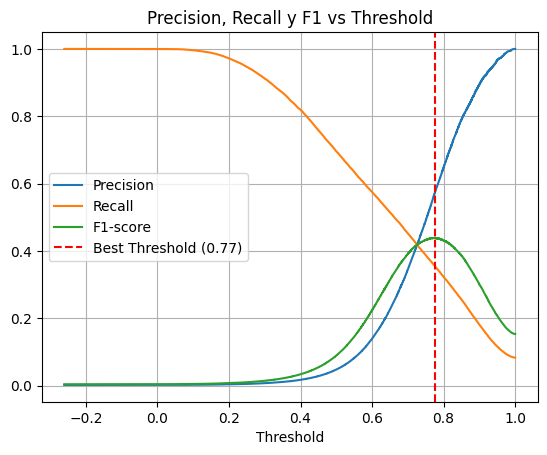

In [ ]:
prec, rec, thresholds = precision_recall_curve(y_true, y_scores)
f1 = 2 * (prec * rec) / (prec + rec + 1e-10)

best_idx = f1.argmax()
best_threshold = thresholds[best_idx]

plt.plot(thresholds, prec[:-1], label="Precision")
plt.plot(thresholds, rec[:-1], label="Recall")
plt.plot(thresholds, f1[:-1], label="F1-score")
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel("Threshold")
plt.legend()
plt.grid(True)
plt.title("Precision, Recall y F1 vs Threshold")
plt.show()

## Evaluación con datos de validación

### Cálculo de matriz de similitud y de relevancia

In [52]:
# calcular la matriz de similitud de query x corpus elements
query_embeddings = model.encode(validation_data['queries']['jobtitle'].tolist(), convert_to_tensor=True, device='cpu', show_progress_bar=True)
corpus_embeddings = model.encode(validation_data['corpus_elements']['jobtitle'].tolist(), convert_to_tensor=True, device='cpu', show_progress_bar=True)

cosine_scores = util.cos_sim(query_embeddings, corpus_embeddings).cpu().numpy()
print('\nMatriz de similitud (query x corpus elements):', cosine_scores.shape)
print(cosine_scores)

Batches: 100%|██████████| 82/82 [00:09<00:00,  8.75it/s]


Matriz de similitud (query x corpus elements): (105, 2619)
[[0.21296816 0.2310408  0.30833417 ... 0.2796646  0.11383708 0.22759824]
 [0.26919237 0.1748625  0.30276865 ... 0.4511308  0.39728913 0.10192341]
 [0.7295592  0.09044953 0.3928468  ... 0.5124594  0.27894348 0.40515035]
 ...
 [0.21932009 0.17697953 0.178989   ... 0.35043252 0.24006447 0.11973904]
 [0.43400556 0.08289627 0.28846532 ... 0.48635602 0.21857396 0.29901707]
 [0.28159153 0.19524384 0.25011295 ... 0.2766195  0.16540116 0.13811007]]


In [54]:
# convertir la matriz cosine_scores en una matriz binaria usando el umbral óptimo encontrado
preds_binary = (cosine_scores >= best_threshold).astype(int)
preds_binary

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(105, 2619))

In [53]:
query_size = validation_data['queries'].shape[0]
corpus_size = validation_data['corpus_elements'].shape[0]

relevance_matrix = np.zeros((query_size, corpus_size), dtype=int)
for index, row in validation_data['qrels'].iterrows():
    relevance_matrix[row['q_id'], row['c_id']] = row['relevance']

relevance_matrix

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(105, 2619))

### Evaluación

In [ ]:
# evaluar las predicciones, teniendo en cuenta que lo importante es identificar correctamente los positivos

print(classification_report(relevance_matrix.flatten(), preds_binary.flatten()))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    272575
           1       0.71      0.25      0.37      2420

    accuracy                           0.99    274995
   macro avg       0.85      0.62      0.68    274995
weighted avg       0.99      0.99      0.99    274995



# Aproximación con fine-tunning